# 日経平均構成銘柄のFat Tail性とVolatility Clustering
yfinanceを使って日経225構成銘柄の日次リターンを取得し、以下を実証する：
1. **Fat Tail（裾の重さ）**: リターン分布が正規分布より裾が厚いことを示す
2. **Volatility Clustering（ボラティリティの集積性）**: 大きな変動の後には大きな変動が続きやすい

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定（Windows）
plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)

## 1. データ取得
日経225の主要構成銘柄からサンプルを取得する（全225銘柄だと時間がかかるため、代表的な30銘柄を使用）

In [15]:
# 日経225主要構成銘柄（東証コード + .T でyfinanceから取得可能）
nikkei_tickers = [
    "7203.T",  # トヨタ
    "6758.T",  # ソニー
    "9984.T",  # ソフトバンクグループ
    "6861.T",  # キーエンス
    "8306.T",  # 三菱UFJ
    "9433.T",  # KDDI
    "6501.T",  # 日立
    "6902.T",  # デンソー
    "4503.T",  # アステラス
    "6367.T",  # ダイキン
    "8035.T",  # 東京エレクトロン
    "4063.T",  # 信越化学
    "7741.T",  # HOYA
    "6098.T",  # リクルート
    "4568.T",  # 第一三共
    "7267.T",  # ホンダ
    "8058.T",  # 三菱商事
    "9432.T",  # NTT
    "6981.T",  # 村田製作所
    "3382.T",  # セブン&アイ
    "4519.T",  # 中外製薬
    "6954.T",  # ファナック
    "7974.T",  # 任天堂
    "2914.T",  # JT
    "8766.T",  # 東京海上HD
    "4502.T",  # 武田薬品
    "6273.T",  # SMC
    "9983.T",  # ファーストリテイリング
    "6594.T",  # 日本電産
    "8001.T",  # 伊藤忠
]

# 過去10年分の日次データを取得
print("データ取得中...")
data = yf.download(nikkei_tickers, period="10y", auto_adjust=True)
prices = data["Close"].dropna(how="all")
print(f"取得期間: {prices.index[0].date()} ~ {prices.index[-1].date()}")
print(f"銘柄数: {prices.shape[1]}, 日数: {prices.shape[0]}")

データ取得中...


[*********************100%***********************]  30 of 30 completed

取得期間: 2016-03-11 ~ 2026-03-11
銘柄数: 30, 日数: 2463


## 2. 日次対数リターンの計算

In [16]:
# 対数リターン: r_t = ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# 全銘柄のリターンを1つにまとめる（プールドリターン）
pooled_returns = log_returns.values.flatten()
pooled_returns = pooled_returns[~np.isnan(pooled_returns)]

print(f"個別銘柄のリターン: {log_returns.shape}")
print(f"プールドリターン数: {len(pooled_returns)}")
print(f"平均: {pooled_returns.mean():.6f}, 標準偏差: {pooled_returns.std():.6f}")

個別銘柄のリターン: (2462, 30)
プールドリターン数: 73860
平均: 0.000592, 標準偏差: 0.019378


## 3. Fat Tail性の実証

### 3-1. リターン分布 vs 正規分布（ヒストグラム）
正規分布と比べてリターン分布の裾が厚い（極端な値が多い）ことを視覚的に確認する

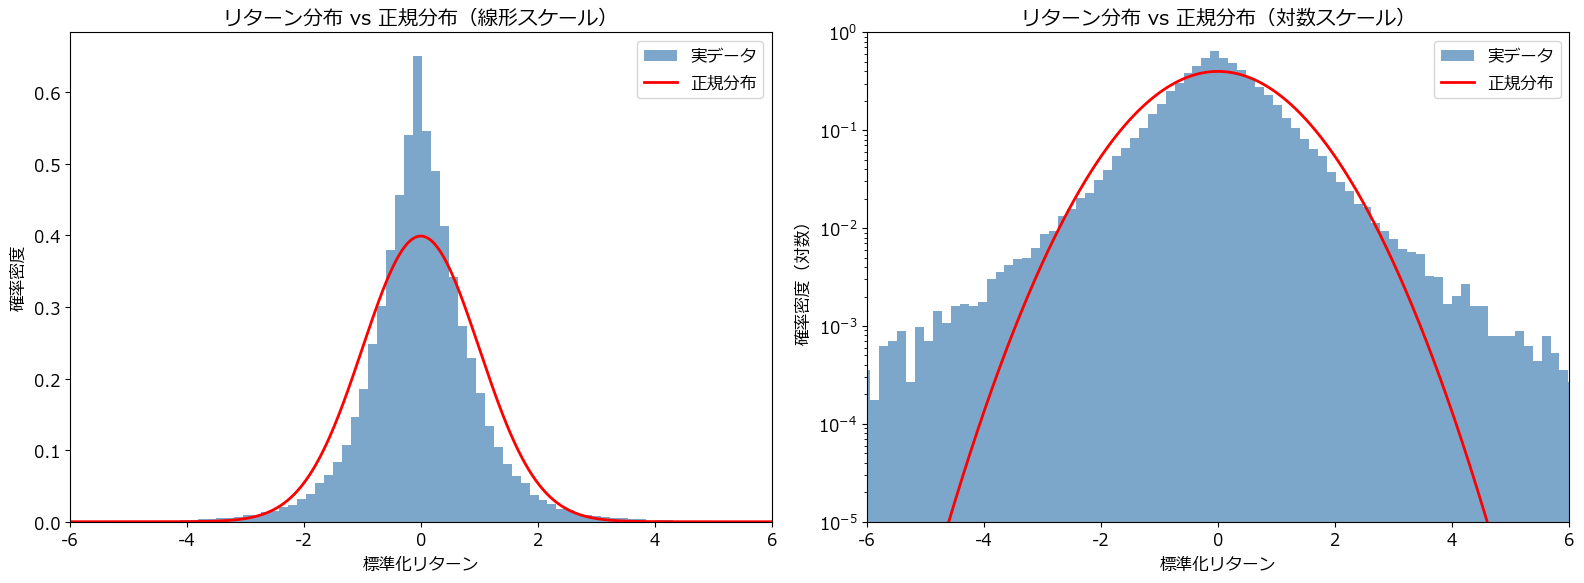

→ 対数スケールで見ると、実データは正規分布より裾が厚い（Fat Tail）ことが明確


In [17]:
# 標準化リターン（平均0, 分散1に揃える）
standardized = (pooled_returns - pooled_returns.mean()) / pooled_returns.std()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左: 線形スケール
axes[0].hist(standardized, bins=200, density=True, alpha=0.7, label="実データ", color="steelblue")
x = np.linspace(-6, 6, 1000)
axes[0].plot(x, stats.norm.pdf(x), 'r-', lw=2, label="正規分布")
axes[0].set_xlim(-6, 6)
axes[0].set_xlabel("標準化リターン")
axes[0].set_ylabel("確率密度")
axes[0].set_title("リターン分布 vs 正規分布（線形スケール）")
axes[0].legend()

# 右: 対数スケール（裾の違いが見やすい）
axes[1].hist(standardized, bins=200, density=True, alpha=0.7, label="実データ", color="steelblue")
axes[1].plot(x, stats.norm.pdf(x), 'r-', lw=2, label="正規分布")
axes[1].set_yscale('log')
axes[1].set_xlim(-6, 6)
axes[1].set_ylim(1e-5, 1)
axes[1].set_xlabel("標準化リターン")
axes[1].set_ylabel("確率密度（対数）")
axes[1].set_title("リターン分布 vs 正規分布（対数スケール）")
axes[1].legend()

plt.tight_layout()
plt.show()
print("→ 対数スケールで見ると、実データは正規分布より裾が厚い（Fat Tail）ことが明確")

### 3-2. QQプロット
データが正規分布に従うなら点は直線上に乗る。裾が外れるほどFat Tailが強い

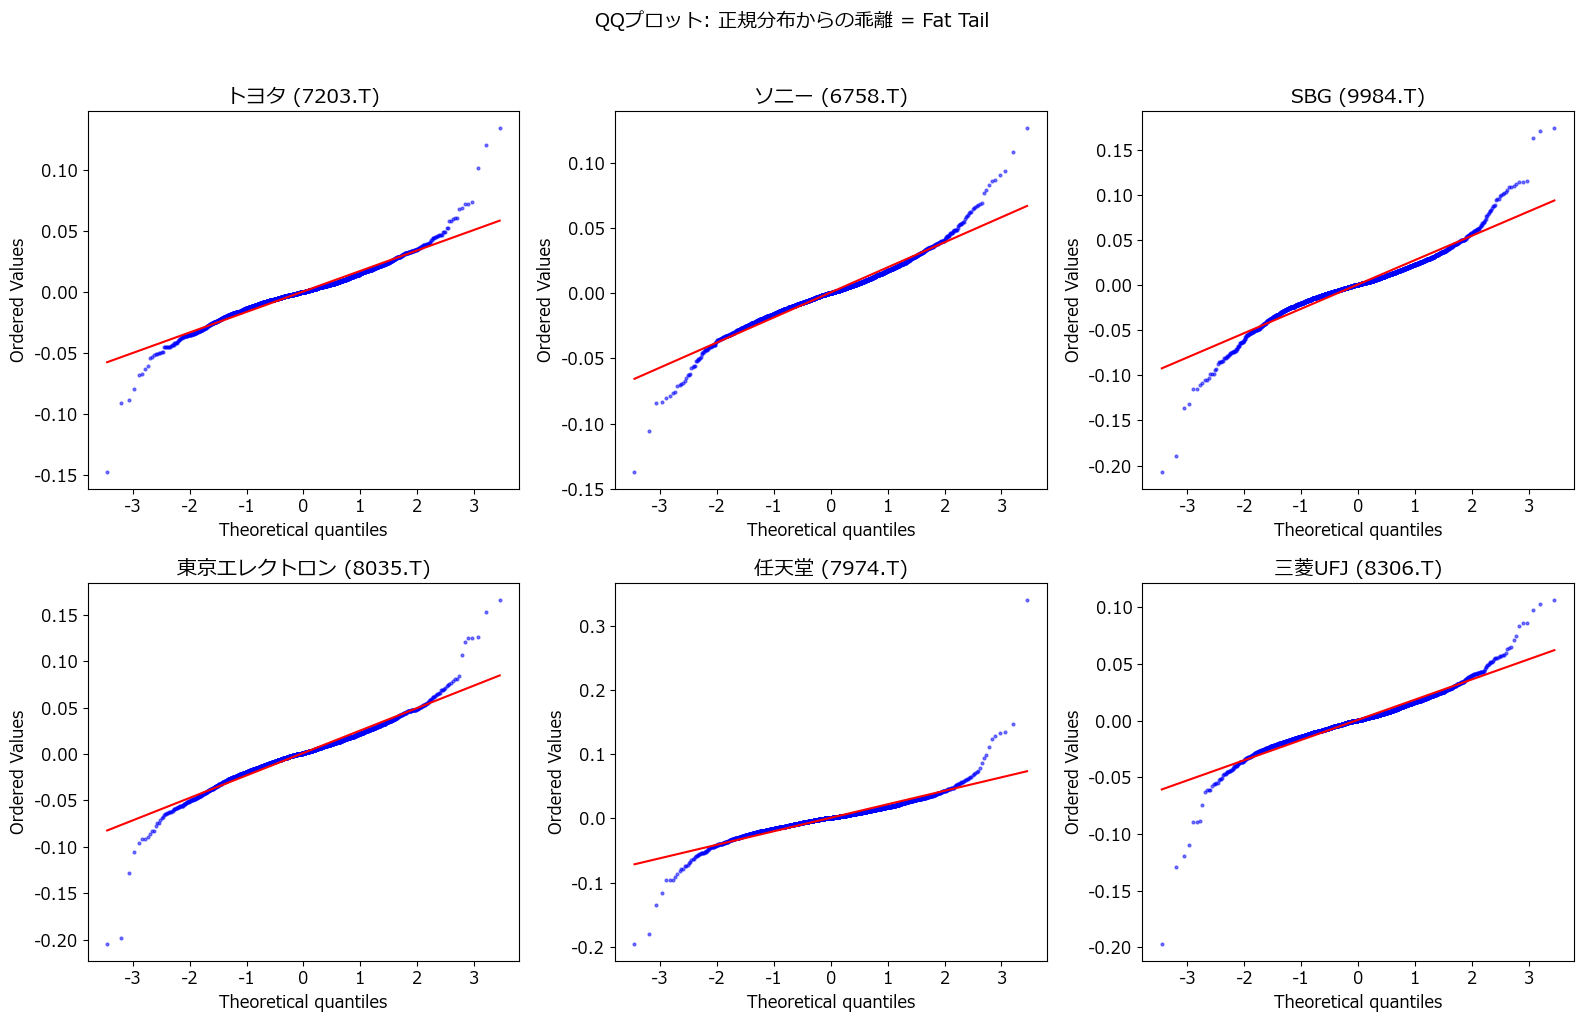

→ 両端が直線から大きく外れている = 正規分布より極端な値が多い


In [18]:
# 代表的な6銘柄のQQプロット
sample_tickers = ["7203.T", "6758.T", "9984.T", "8035.T", "7974.T", "8306.T"]
ticker_names = ["トヨタ", "ソニー", "SBG", "東京エレクトロン", "任天堂", "三菱UFJ"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, ticker, name in zip(axes.flatten(), sample_tickers, ticker_names):
    r = log_returns[ticker].dropna().values
    stats.probplot(r, dist="norm", plot=ax)
    ax.set_title(f"{name} ({ticker})")
    ax.get_lines()[0].set(markersize=2, alpha=0.5)

plt.suptitle("QQプロット: 正規分布からの乖離 = Fat Tail", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print("→ 両端が直線から大きく外れている = 正規分布より極端な値が多い")

### 3-3. 尖度（Kurtosis）の計測
正規分布の超過尖度 = 0。値が大きいほど裾が厚い（Fat Tail）

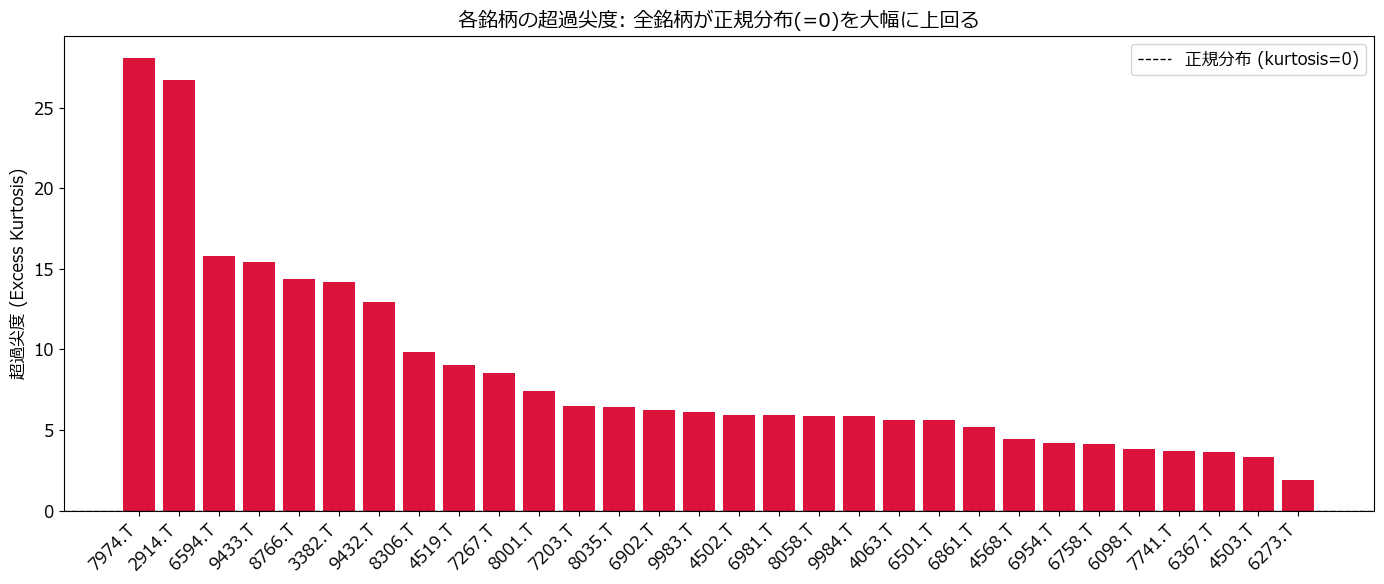


プールドリターンの超過尖度: 9.16
全銘柄の平均超過尖度: 8.57
最小の超過尖度: 1.91 (6273.T)
→ 全銘柄で超過尖度 > 0 → Fat Tailが普遍的に存在する


In [19]:
# 各銘柄の超過尖度（excess kurtosis）を計算
kurtosis_vals = log_returns.kurtosis().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['crimson' if k > 0 else 'steelblue' for k in kurtosis_vals.values]
ax.bar(range(len(kurtosis_vals)), kurtosis_vals.values, color=colors)
ax.axhline(y=0, color='black', linestyle='--', lw=1, label='正規分布 (kurtosis=0)')
ax.set_xticks(range(len(kurtosis_vals)))
ax.set_xticklabels(kurtosis_vals.index, rotation=45, ha='right')
ax.set_ylabel("超過尖度 (Excess Kurtosis)")
ax.set_title("各銘柄の超過尖度: 全銘柄が正規分布(=0)を大幅に上回る")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nプールドリターンの超過尖度: {stats.kurtosis(pooled_returns):.2f}")
print(f"全銘柄の平均超過尖度: {kurtosis_vals.mean():.2f}")
print(f"最小の超過尖度: {kurtosis_vals.min():.2f} ({kurtosis_vals.index[-1]})")
print("→ 全銘柄で超過尖度 > 0 → Fat Tailが普遍的に存在する")

### 3-4. 正規性の統計検定（Jarque-Bera検定）
帰無仮説「リターンは正規分布に従う」を検定する。p値が小さければ正規分布を棄却 → Fat Tail

In [20]:
# Jarque-Bera検定: p < 0.05 なら正規分布を棄却
jb_results = []
for ticker in log_returns.columns:
    r = log_returns[ticker].dropna().values
    jb_stat, p_val = stats.jarque_bera(r)
    jb_results.append({"銘柄": ticker, "JB統計量": jb_stat, "p値": p_val})

jb_df = pd.DataFrame(jb_results).sort_values("JB統計量", ascending=False)
jb_df["正規分布を棄却?"] = jb_df["p値"].apply(lambda p: "✓ 棄却" if p < 0.05 else "棄却できず")

print(jb_df.to_string(index=False))
print(f"\n棄却された銘柄数: {(jb_df['p値'] < 0.05).sum()} / {len(jb_df)}")
print("→ 全銘柄で正規分布が棄却される = Fat Tailは統計的にも有意")

    銘柄        JB統計量            p値 正規分布を棄却?
7974.T 80923.691825  0.000000e+00     ✓ 棄却
2914.T 73265.858611  0.000000e+00     ✓ 棄却
6594.T 26010.898245  0.000000e+00     ✓ 棄却
9433.T 24813.385790  0.000000e+00     ✓ 棄却
8766.T 21158.988435  0.000000e+00     ✓ 棄却
3382.T 20631.652599  0.000000e+00     ✓ 棄却
9432.T 17355.266297  0.000000e+00     ✓ 棄却
8306.T 10054.529233  0.000000e+00     ✓ 棄却
4519.T  8327.934712  0.000000e+00     ✓ 棄却
7267.T  7427.220062  0.000000e+00     ✓ 棄却
8001.T  5693.618576  0.000000e+00     ✓ 棄却
8035.T  4284.282344  0.000000e+00     ✓ 棄却
7203.T  4280.658115  0.000000e+00     ✓ 棄却
6902.T  4001.206620  0.000000e+00     ✓ 棄却
9983.T  3861.377072  0.000000e+00     ✓ 棄却
4502.T  3671.927714  0.000000e+00     ✓ 棄却
6981.T  3662.776469  0.000000e+00     ✓ 棄却
8058.T  3536.950864  0.000000e+00     ✓ 棄却
9984.T  3525.383560  0.000000e+00     ✓ 棄却
4063.T  3270.712955  0.000000e+00     ✓ 棄却
6501.T  3254.401545  0.000000e+00     ✓ 棄却
6861.T  2815.355181  0.000000e+00     ✓ 棄却
4568.T  203

## 4. Volatility Clusteringの実証

### 4-1. リターンの時系列プロット
大きな変動が連続して起きる「かたまり」が視覚的に確認できる

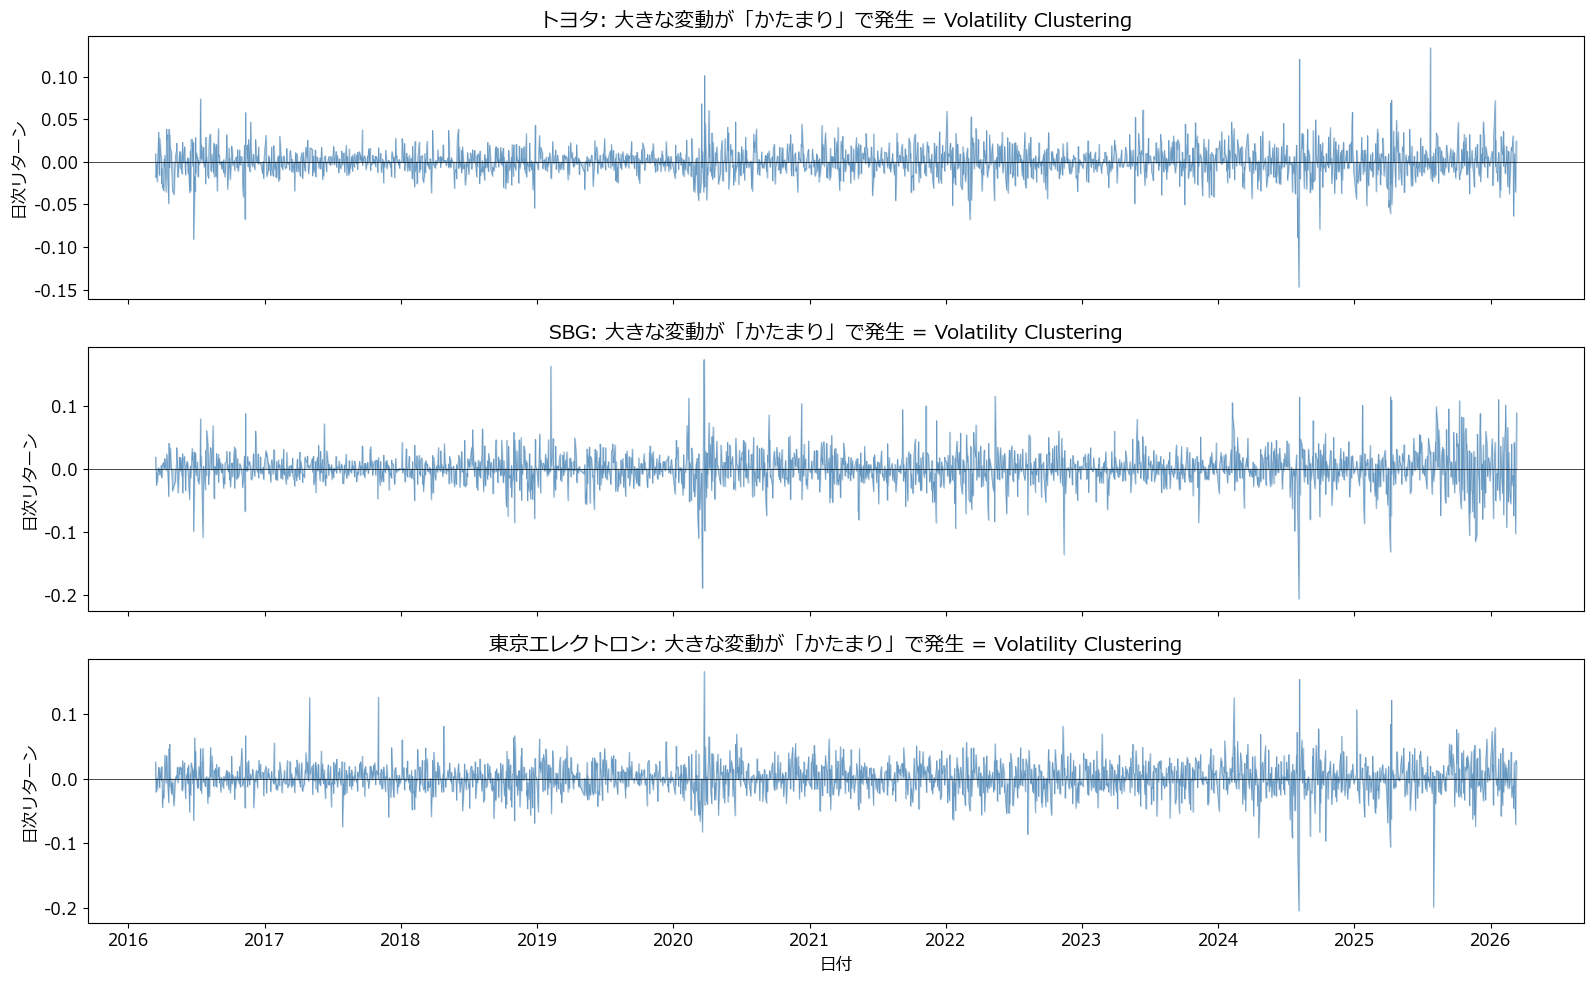

→ 変動が大きい時期と穏やかな時期が交互に現れる（iid過程ではこうならない）


In [21]:
# 代表3銘柄のリターン時系列
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
plot_tickers = [("7203.T", "トヨタ"), ("9984.T", "SBG"), ("8035.T", "東京エレクトロン")]

for ax, (ticker, name) in zip(axes, plot_tickers):
    r = log_returns[ticker].dropna()
    ax.plot(r.index, r.values, color="steelblue", alpha=0.7, lw=0.5)
    ax.fill_between(r.index, r.values, 0, alpha=0.3, color="steelblue")
    ax.set_ylabel("日次リターン")
    ax.set_title(f"{name}: 大きな変動が「かたまり」で発生 = Volatility Clustering")
    ax.axhline(0, color='black', lw=0.5)

plt.xlabel("日付")
plt.tight_layout()
plt.show()
print("→ 変動が大きい時期と穏やかな時期が交互に現れる（iid過程ではこうならない）")

### 4-2. 絶対リターンの自己相関関数（ACF）
Volatility Clusteringが存在すれば、|r_t| の自己相関が正かつ緩やかに減衰する（長期記憶）

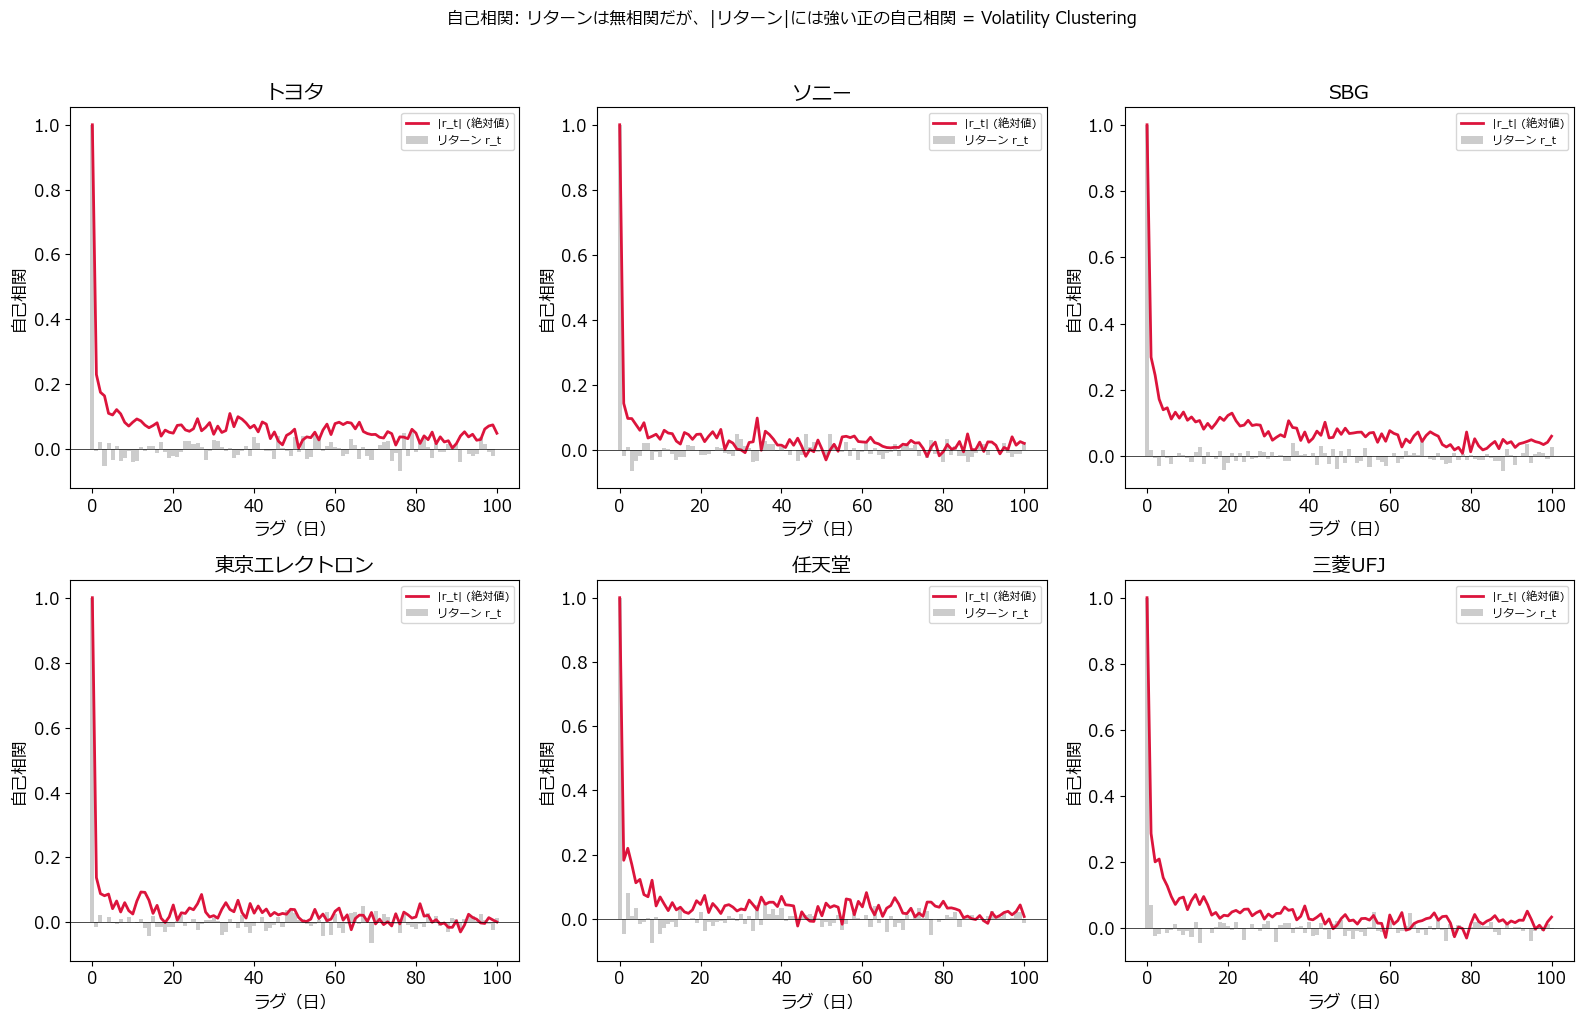

→ リターン自体はほぼ無相関（灰色）だが、絶対リターンは長くラグが持続（赤）


In [22]:
from statsmodels.tsa.stattools import acf

max_lag = 100
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, (ticker, name) in zip(axes.flatten(), zip(sample_tickers, ticker_names)):
    r = log_returns[ticker].dropna()
    
    # リターンそのものの自己相関
    acf_r = acf(r, nlags=max_lag, fft=True)
    # 絶対リターンの自己相関
    acf_abs = acf(r.abs(), nlags=max_lag, fft=True)
    
    lags = np.arange(max_lag + 1)
    ax.bar(lags, acf_r, alpha=0.4, color='gray', label='リターン r_t', width=1)
    ax.plot(lags, acf_abs, color='crimson', lw=2, label='|r_t| (絶対値)')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f"{name}")
    ax.set_xlabel("ラグ（日）")
    ax.set_ylabel("自己相関")
    ax.legend(fontsize=8)

plt.suptitle("自己相関: リターンは無相関だが、|リターン|には強い正の自己相関 = Volatility Clustering", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("→ リターン自体はほぼ無相関（灰色）だが、絶対リターンは長くラグが持続（赤）")

### 4-3. Ljung-Box検定
絶対リターンの自己相関がゼロかどうかを統計的に検定する。p < 0.05 なら「自己相関あり」= Volatility Clustering

In [23]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_results = []
for ticker in log_returns.columns:
    r = log_returns[ticker].dropna()
    # 絶対リターンに対してLjung-Box検定（ラグ20）
    lb = acorr_ljungbox(r.abs(), lags=20, return_df=True)
    lb_stat = lb["lb_stat"].iloc[-1]
    lb_pval = lb["lb_pvalue"].iloc[-1]
    lb_results.append({"銘柄": ticker, "LB統計量(lag20)": lb_stat, "p値": lb_pval})

lb_df = pd.DataFrame(lb_results).sort_values("LB統計量(lag20)", ascending=False)
lb_df["VC存在?"] = lb_df["p値"].apply(lambda p: "✓ 存在" if p < 0.05 else "存在せず")

print(lb_df.to_string(index=False))
print(f"\nVolatility Clustering確認: {(lb_df['p値'] < 0.05).sum()} / {len(lb_df)} 銘柄")
print("→ 絶対リターンに有意な自己相関 = Volatility Clusteringが統計的にも確認")

    銘柄  LB統計量(lag20)            p値 VC存在?
9984.T    994.308515 6.385935e-198  ✓ 存在
6098.T    834.795838 5.767929e-164  ✓ 存在
8766.T    717.819225 3.746588e-139  ✓ 存在
8306.T    697.756749 6.601876e-135  ✓ 存在
4502.T    603.618649 4.975183e-115  ✓ 存在
6501.T    559.487815 9.638208e-106  ✓ 存在
7203.T    551.141764 5.467508e-104  ✓ 存在
7974.T    449.919876  8.471747e-83  ✓ 存在
6981.T    444.455184  1.167001e-81  ✓ 存在
3382.T    410.620992  1.276701e-74  ✓ 存在
6902.T    397.479415  6.811764e-72  ✓ 存在
8001.T    374.401789  4.092316e-67  ✓ 存在
9432.T    350.929639  2.865979e-62  ✓ 存在
2914.T    338.050662  1.284242e-59  ✓ 存在
4503.T    321.827784  2.756719e-56  ✓ 存在
9433.T    315.700110  4.969967e-55  ✓ 存在
6954.T    306.569840  3.673080e-53  ✓ 存在
4063.T    299.946987  8.286863e-52  ✓ 存在
7267.T    297.077595  3.192738e-51  ✓ 存在
9983.T    289.197250  1.291306e-49  ✓ 存在
8058.T    283.385832  1.968795e-48  ✓ 存在
6594.T    261.256917  6.082770e-44  ✓ 存在
8035.T    215.518327  9.345437e-35  ✓ 存在
6861.T    213.36

## 5. まとめ

In [24]:
# 全銘柄の統計まとめ
summary = pd.DataFrame({
    "銘柄": log_returns.columns,
    "平均リターン": log_returns.mean().values,
    "標準偏差": log_returns.std().values,
    "歪度": log_returns.skew().values,
    "超過尖度": log_returns.kurtosis().values,
})
summary["Fat Tail"] = summary["超過尖度"].apply(lambda k: "✓" if k > 0 else "")

print("=" * 70)
print("   日経225構成銘柄 — Fat Tail & Volatility Clustering 実証結果")  
print("=" * 70)
print(f"\n【Fat Tail】")
print(f"  全 {len(summary)} 銘柄の超過尖度 > 0 → 正規分布より裾が厚い")
print(f"  平均超過尖度: {summary['超過尖度'].mean():.2f} (正規分布=0)")
print(f"  Jarque-Bera検定: 全銘柄で正規分布を棄却\n")
print(f"【Volatility Clustering】")
print(f"  絶対リターンの自己相関が正かつ持続")
print(f"  Ljung-Box検定: 大多数の銘柄で自己相関が有意\n")
print(f"→ 効率的市場仮説が前提とするiid正規分布では説明できないstylized facts")
print(f"  これらは経済物理学（Econophysics）の主要な研究対象である")
print("=" * 70)

   日経225構成銘柄 — Fat Tail & Volatility Clustering 実証結果

【Fat Tail】
  全 30 銘柄の超過尖度 > 0 → 正規分布より裾が厚い
  平均超過尖度: 8.57 (正規分布=0)
  Jarque-Bera検定: 全銘柄で正規分布を棄却

【Volatility Clustering】
  絶対リターンの自己相関が正かつ持続
  Ljung-Box検定: 大多数の銘柄で自己相関が有意

→ 効率的市場仮説が前提とするiid正規分布では説明できないstylized facts
  これらは経済物理学（Econophysics）の主要な研究対象である
